In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [28]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Plot correlations

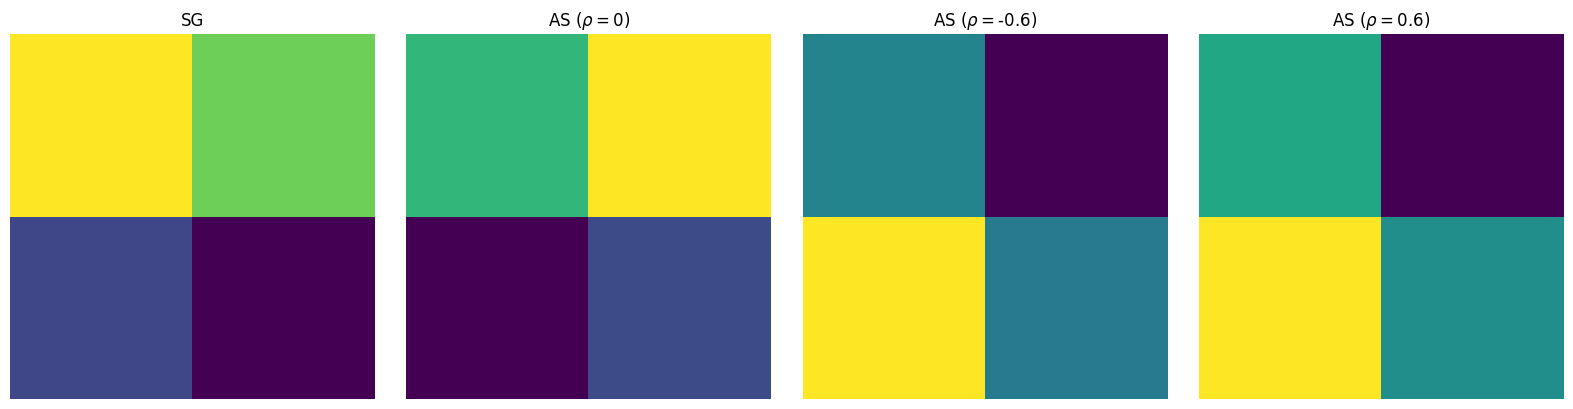

In [3]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 2
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0, -0.6, 0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [53]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.0, -0.6, 0.6]),
    tau_sampling=True, # tau=0.03,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type      tau
Step AgentID                                                         
1    1        (1, 1) -0.506076          -0.506076     SG-ICM  0.00881
     2        (0, 0)  0.493290           0.493290         AS  0.00881
     3        (1, 1)  0.345250           0.345250         AS  0.00881
     4        (0, 1) -0.260604          -0.260604         AS  0.00881
2    1        (0, 0)  0.504969          -0.501108     SG-ICM  0.00881
     2        (1, 1) -0.484769          -0.491479         AS  0.00881
     3        (0, 0)  0.133300          -0.021450         AS  0.00881
     4        (1, 0)  0.166914          -0.593690         AS  0.00881
3    1        (0, 0)  0.511090          -0.490017     SG-ICM  0.00881
     2        (0, 0)  0.511642          -0.479837         AS  0.00881
     3        (0, 1)  0.055478          -0.465972         AS  0.00881
     4        (1, 0)  0.157915          -0.935775         AS  0.00881
4    1        (0, 0)  0.500033          -0.489985     SG-ICM  0.00881
     2        (0, 0)  0.496743          -0.483094         AS  0.00881
     3        (1, 0)  0.404329          -0.561643         AS  0.00881
     4        (1, 0)  0.169333          -1.266442         AS  0.00881
5    1        (0, 0)  0.489292          -0.500693     SG-ICM  0.00881
     2        (0, 0)  0.492236          -0.490858         AS  0.00881
     3        (1, 0)  0.411834          -0.649809         AS  0.00881
     4        (0, 0) -0.511911          -2.278353         AS  0.00881

In [77]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "length_scale_private": 1.11,
    "beta_private": 0.33,
    "beta_social": 0.33,
    "tau_sampling": True,
    "seed": list(range(100)),
    "network_type": "directed_one_to_four",
    "rho": [np.array([1.0, 0.0, -0.6, 0.6]), 
            np.array([1.0, 0.0, 0.0, 0.0]), 
            np.array([1.0, 0.5, 0.6, -0.6])],
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/300 [00:00<?, ?it/s]

In [78]:
batch_results.head()

,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,length_scale_private,beta_private,beta_social,tau_sampling,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau
0,0,0,0,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, 0.0, -0.6, 0.6]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",0.458391,0.458391,NaN,NaN,NaN,NaN,NaN
1,0,0,1,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, 0.0, -0.6, 0.6]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.109260,0.554630,1.0,"(9, 9)",0.428896,0.428896,0.012208
2,0,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, 0.0, -0.6, 0.6]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.109260,0.554630,2.0,"(5, 4)",0.442443,0.442443,0.012208
3,0,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, 0.0, -0.6, 0.6]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.109260,0.554630,3.0,"(9, 8)",0.382462,0.382462,0.012208
4,0,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, 0.0, -0.6, 0.6]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.109260,0.554630,4.0,"(3, 10)",0.579764,0.579764,0.012208


In [79]:
batch_results['rho_str'] = [str(l) for l in batch_results['rho'].to_list()]

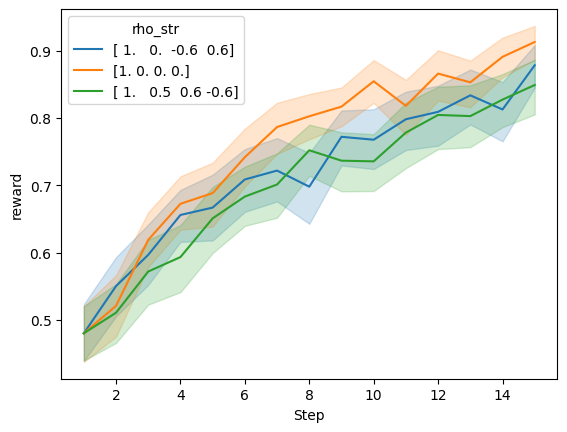

In [80]:
sns.lineplot(batch_results[batch_results.model_type == "SG-ICM"],
             x="Step",
             y="reward",
             hue="rho_str",
             hue_order=["[ 1.   0.  -0.6  0.6]", "[1. 0. 0. 0.]", "[ 1.   0.5  0.6 -0.6]"]
             )
plt.show()

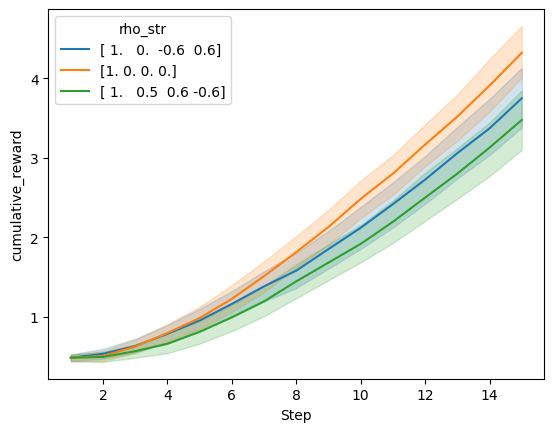

In [81]:
sns.lineplot(batch_results[batch_results.model_type == "SG-ICM"],
             x="Step",
             y="cumulative_reward",
             hue="rho_str",
             hue_order=["[ 1.   0.  -0.6  0.6]", "[1. 0. 0. 0.]", "[ 1.   0.5  0.6 -0.6]"]
             )
plt.show()